# Hartmann 6D: SMAC surrogate RF depth comparison

Comparison of the default SMAC random-forest surrogate with `max_depth` values 2, 4, 7, 10, 15, 20, and 25. Each setting contains five independent seeds.

In [14]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "master_utils").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from master_utils.reload_components import load_smac_components

RESULTS_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "hartmann"
    / "03_fixed_depths"
    / "hartmann_6d_fixed_depths"
)
SETTINGS = {
    "Default": "default",
    "Depth 2": "depth_2",
    "Depth 4": "depth_4",
    "Depth 7": "depth_7",
    "Depth 10": "depth_10",
    "Depth 15": "depth_15",
    "Depth 20": "depth_20",
    "Depth 25": "depth_25",
}
SEEDS = range(5)
N_TRIALS = 500
HARTMANN_6D_MINIMUM = -3.322368011415515
CONFIDENCE = 0.95

plt.rcParams.update({"figure.figsize": (10, 6), "axes.grid": True})

## Load the 40 SMAC runs

In [15]:
runs = {
    label: {
        seed: load_smac_components(RESULTS_DIR / directory / str(seed))
        for seed in SEEDS
    }
    for label, directory in SETTINGS.items()
}


def incumbent_trajectory(runhistory):
    trials = sorted(runhistory.items(), key=lambda item: item[1].starttime)
    costs = np.asarray([value.cost for _, value in trials], dtype=float)
    return np.minimum.accumulate(costs)


incumbent_costs = {}
for label, setting_runs in runs.items():
    trajectories = [
        incumbent_trajectory(setting_runs[seed]["runhistory"])
        for seed in SEEDS
    ]
    lengths = [len(trajectory) for trajectory in trajectories]
    assert min(lengths) >= N_TRIALS, f"{label}: {lengths}"
    incumbent_costs[label] = np.vstack(
        [trajectory[:N_TRIALS] for trajectory in trajectories]
    )

trial_numbers = np.arange(1, N_TRIALS + 1)
{label: values.shape for label, values in incumbent_costs.items()}

{'Default': (5, 500),
 'Depth 2': (5, 500),
 'Depth 4': (5, 500),
 'Depth 7': (5, 500),
 'Depth 10': (5, 500),
 'Depth 15': (5, 500),
 'Depth 20': (5, 500),
 'Depth 25': (5, 500)}

In [16]:
def mean_and_ci(values, confidence=CONFIDENCE):
    values = np.asarray(values, dtype=float)
    mean = values.mean(axis=0)
    sem = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0])
    critical_value = t.ppf((1 + confidence) / 2, df=values.shape[0] - 1)
    half_width = critical_value * sem
    return mean, mean - half_width, mean + half_width


colors = dict(zip(SETTINGS, plt.get_cmap("tab10").colors))

## 1. Final incumbent performance by RF setting

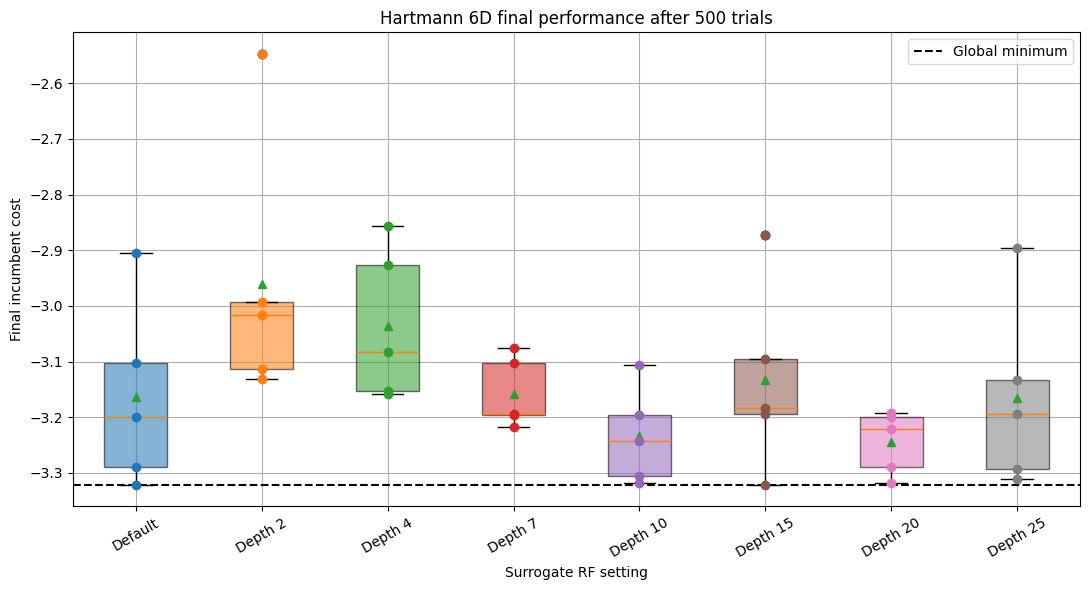

In [17]:
labels = list(SETTINGS)
final_costs = [incumbent_costs[label][:, -1] for label in labels]

fig, ax = plt.subplots(figsize=(11, 6))
boxplot = ax.boxplot(final_costs, tick_labels=labels, showmeans=True, patch_artist=True)
for patch, label in zip(boxplot["boxes"], labels):
    patch.set_facecolor(colors[label])
    patch.set_alpha(0.55)
for position, values in enumerate(final_costs, start=1):
    ax.scatter(np.full(len(values), position), values, color=colors[labels[position - 1]], zorder=3)
ax.axhline(HARTMANN_6D_MINIMUM, color="black", linestyle="--", label="Global minimum")
ax.set_xlabel("Surrogate RF setting")
ax.set_ylabel("Final incumbent cost")
ax.set_title("Hartmann 6D final performance after 500 trials")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Mean simple regret with 95% confidence intervals

At each trial, simple regret is the best observed cost minus the known Hartmann-6 global minimum. Confidence intervals are pointwise Student's $t$ intervals across the five seeds.

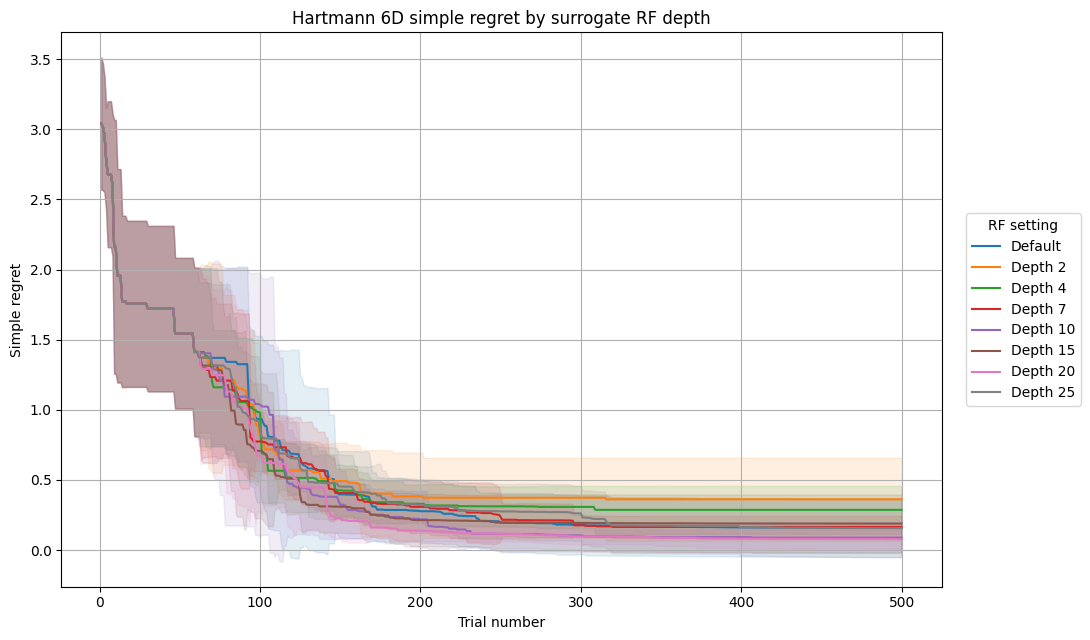

In [18]:
simple_regrets = {
    label: values - HARTMANN_6D_MINIMUM
    for label, values in incumbent_costs.items()
}

fig, ax = plt.subplots(figsize=(11, 6.5))
for label, regrets in simple_regrets.items():
    mean, lower, upper = mean_and_ci(regrets)
    ax.plot(trial_numbers, mean, color=colors[label], label=label)
    ax.fill_between(trial_numbers, lower, upper, color=colors[label], alpha=0.12)
ax.set_xlabel("Trial number")
ax.set_ylabel("Simple regret")
ax.set_title("Hartmann 6D simple regret by surrogate RF depth")
ax.legend(
    title="RF setting",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
plt.tight_layout()
plt.show()

## 3. Mean log-simple-regret with 95% confidence intervals

The logarithm is applied before calculating the mean and Student's $t$ confidence interval. The resulting line estimates mean log-regret (equivalently, its inverse transform is the geometric mean regret).

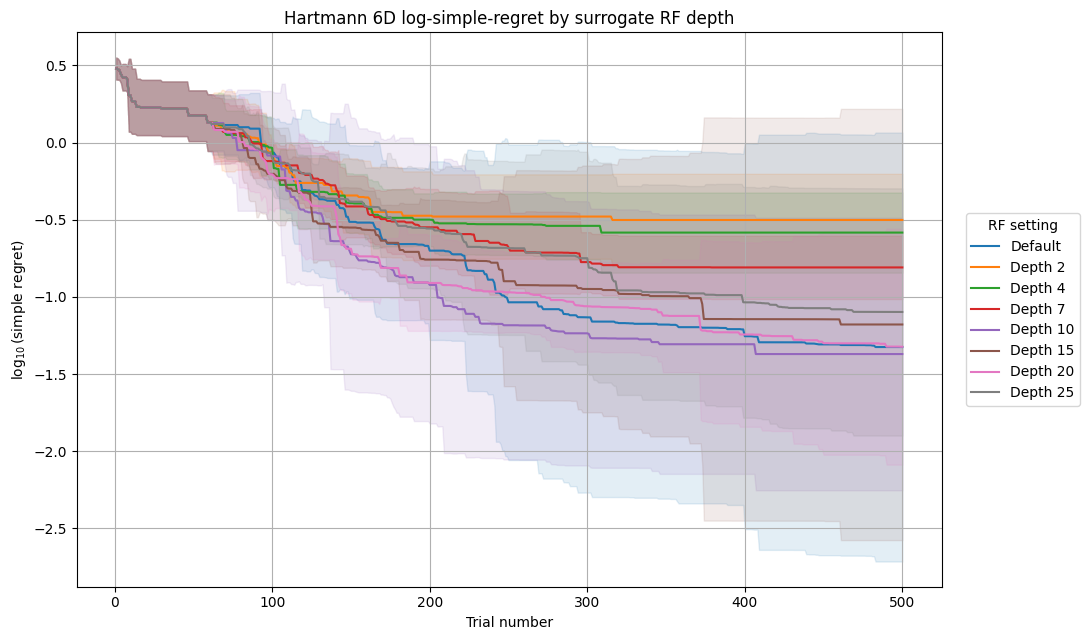

In [19]:
log10_simple_regrets = {
    label: np.log10(regrets)
    for label, regrets in simple_regrets.items()
}

fig, ax = plt.subplots(figsize=(11, 6.5))
for label, log_regrets in log10_simple_regrets.items():
    mean, lower, upper = mean_and_ci(log_regrets)
    ax.plot(trial_numbers, mean, color=colors[label], label=label)
    ax.fill_between(
        trial_numbers,
        lower,
        upper,
        color=colors[label],
        alpha=0.12,
    )
ax.set_xlabel("Trial number")
ax.set_ylabel(r"$\log_{10}$(simple regret)")
ax.set_title("Hartmann 6D log-simple-regret by surrogate RF depth")
ax.legend(
    title="RF setting",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)
plt.tight_layout()
plt.show()

## 4. Best-performing configuration at trial milestones

Each figure compares the incumbent cost across the five seeds for every RF setting at the specified trial number.

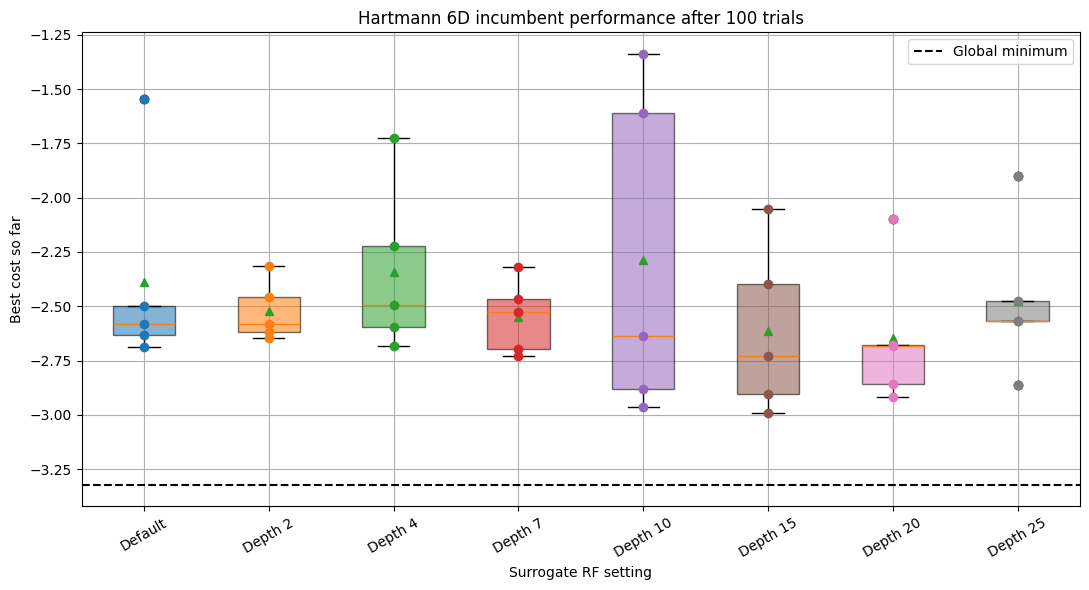

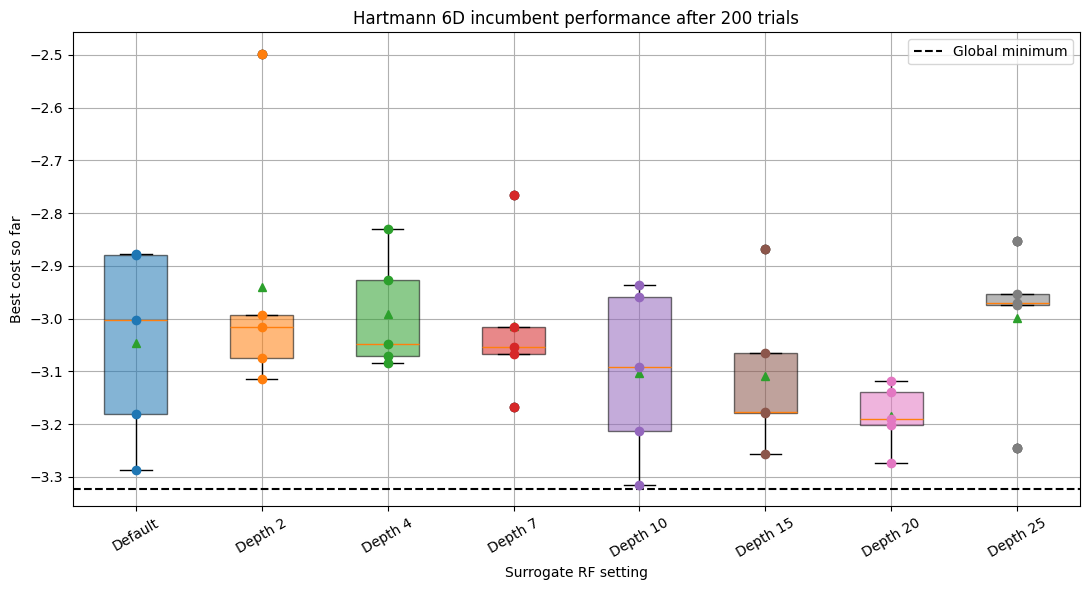

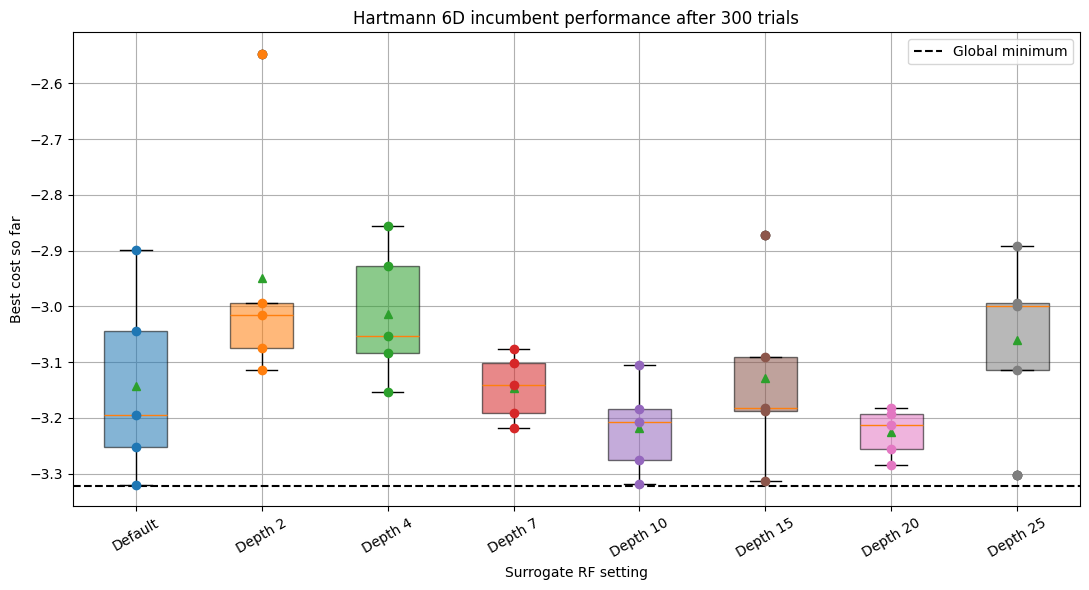

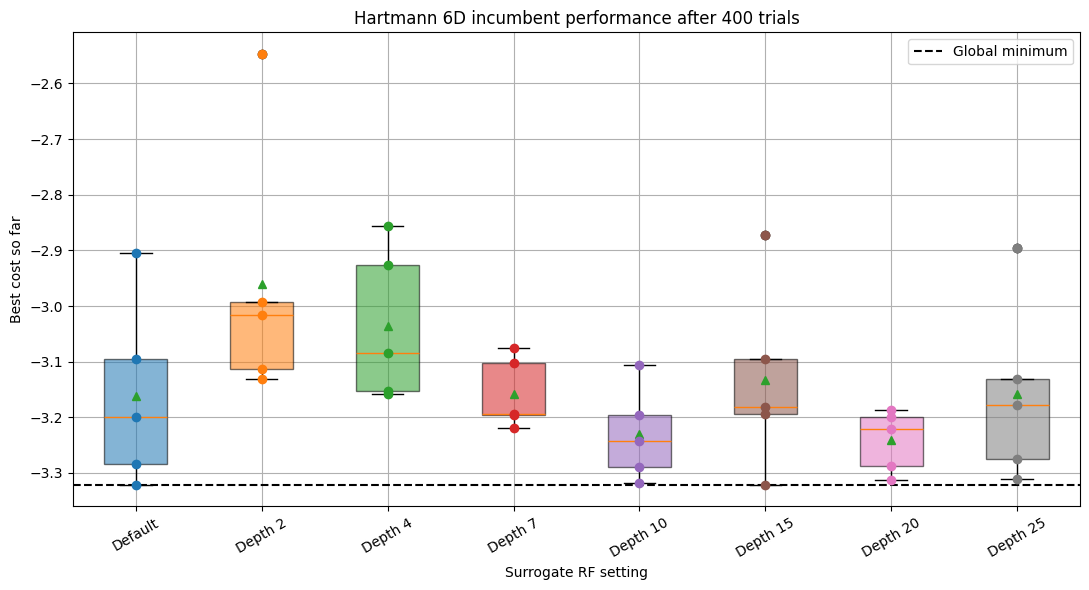

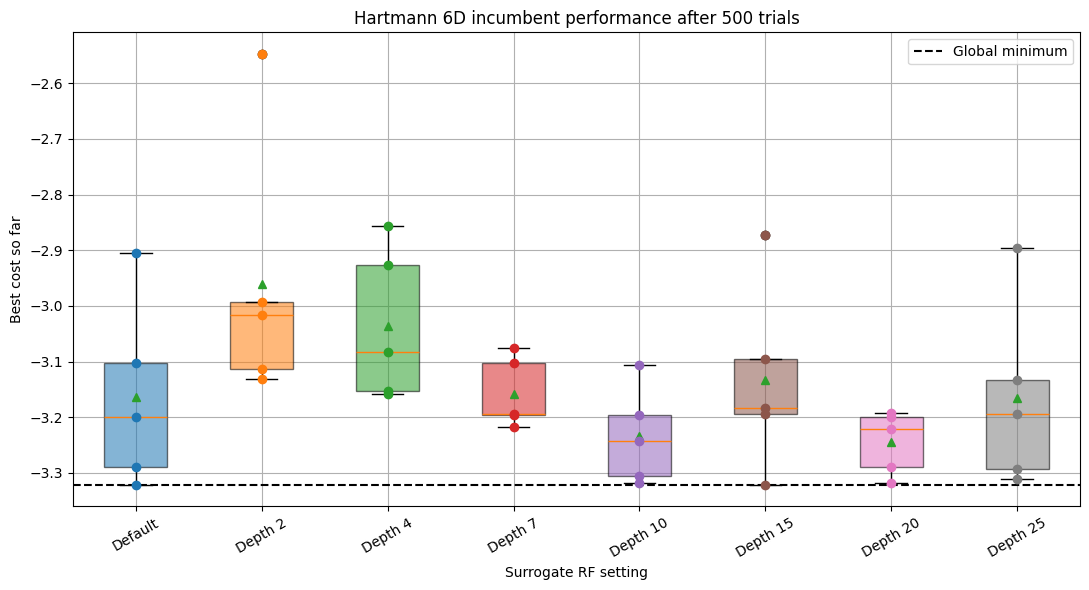

In [20]:
milestones = [100, 200, 300, 400, 500]
labels = list(SETTINGS)

for milestone in milestones:
    milestone_costs = [
        incumbent_costs[label][:, milestone - 1]
        for label in labels
    ]

    fig, ax = plt.subplots(figsize=(11, 6))
    boxplot = ax.boxplot(
        milestone_costs,
        tick_labels=labels,
        showmeans=True,
        patch_artist=True,
    )
    for patch, label in zip(boxplot["boxes"], labels):
        patch.set_facecolor(colors[label])
        patch.set_alpha(0.55)
    for position, values in enumerate(milestone_costs, start=1):
        ax.scatter(
            np.full(len(values), position),
            values,
            color=colors[labels[position - 1]],
            zorder=3,
        )
    ax.axhline(
        HARTMANN_6D_MINIMUM,
        color="black",
        linestyle="--",
        label="Global minimum",
    )
    ax.set_xlabel("Surrogate RF setting")
    ax.set_ylabel("Best cost so far")
    ax.set_title(f"Hartmann 6D incumbent performance after {milestone} trials")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()